# Phân tích độ nhất quán giữa nội dung review và rating

Notebook này sử dụng trực tiếp các module production. Bài toán dự đoán rating từ nội dung tiếng Anh và không kết luận review là giả hoặc spam.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DEFAULT_DATA_PATH
from src.predict import load_resources
from src.preprocessing import prepare_dataset
from src.train import make_holdout_split

## 1. Kiểm tra và làm sạch dữ liệu

In [2]:
raw_df = pd.read_csv(DEFAULT_DATA_PATH)
clean_df, data_report = prepare_dataset(raw_df)

pd.Series(data_report, name='value')

total_raw                                                                                       10000
total_clean                                                                                      9311
removed_total                                                                                     689
missing_review                                                                                     45
missing_rating                                                                                     38
non_numeric_rating                                                                                  1
outside_rating                                                                                      0
half_star_count                                                                                   144
empty_after_cleaning                                                                               16
exact_duplicate_rows                                                              

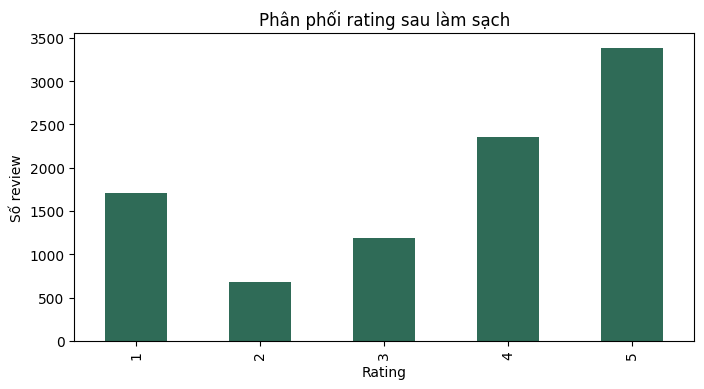

In [3]:
distribution = clean_df['Rating'].value_counts().sort_index()
ax = distribution.plot(kind='bar', color='#2f6b57', figsize=(8, 4))
ax.set_title('Phân phối rating sau làm sạch')
ax.set_xlabel('Rating')
ax.set_ylabel('Số review')
plt.show()

## 2. Kiểm tra group holdout

In [4]:
train_index, test_index = make_holdout_split(clean_df)
train_groups = set(clean_df.iloc[train_index]['text_clean'])
test_groups = set(clean_df.iloc[test_index]['text_clean'])

print('Train rows:', len(train_index))
print('Test rows:', len(test_index))
print('Group overlap:', len(train_groups.intersection(test_groups)))

Train rows: 7449
Test rows: 1862
Group overlap: 0


## 3. Cấu hình, tuning và baseline

In [5]:
pipeline, metadata = load_resources(use_cache=False)

print('Selected parameters:', metadata['selected_parameters'])
print('Class weights:', metadata['class_weights'])
print('Uncertainty threshold:', metadata['uncertainty_threshold'])

pd.DataFrame(metadata['tuning_results'])

Selected parameters: {'weight_power': 1.0, 'C': 0.25}
Class weights: {'1': 1.0922287390029326, '2': 2.723583180987203, '3': 1.5698630136986302, '4': 0.792868547099521, '5': 0.5497416974169742}
Uncertainty threshold: {'value': 0.36, 'coverage': 0.688011813666264, 'accuracy': 0.7014634146341463}


,weight_power,C,macro_f1,weighted_f1,mae,fit_seconds
0,1.00,0.25,0.548610,0.620292,0.480063,1.356599
1,1.00,0.50,0.547107,0.621374,0.476170,1.796865
2,0.80,0.25,0.545887,0.623206,0.475766,1.437161
3,0.80,0.50,0.545570,0.623327,0.468920,1.926737
4,1.00,1.00,0.541749,0.618831,0.475231,2.543734
5,0.80,1.00,0.538870,0.619149,0.474022,2.343854
6,0.65,1.00,0.536658,0.618854,0.473618,2.441632
7,0.65,0.50,0.536509,0.620400,0.471067,2.386878
8,0.65,0.25,0.534495,0.619472,0.475766,1.390562


In [6]:
pd.DataFrame(metadata['model_comparison']).sort_values('macro_f1', ascending=False)

,name,accuracy,macro_f1,weighted_f1,mae,within_one_star
0,weighted_logistic_regression,0.616861,0.548873,0.620441,0.480064,0.929923
1,linear_svm,0.601020,0.507214,0.593468,0.516579,0.913411
2,unweighted_logistic_regression,0.626527,0.469387,0.584064,0.507048,0.909250
3,complement_naive_bayes,0.601155,0.452730,0.561525,0.585045,0.881326


## 4. Kết quả holdout

In [7]:
holdout_metrics = metadata['holdout_metrics']
pd.Series({key: value for key, value in holdout_metrics.items() if key not in {'confusion_matrix', 'recall_per_class'}})

accuracy             0.628894
macro_f1             0.573742
weighted_f1          0.634859
balanced_accuracy    0.582520
mae                  0.459184
within_one_star      0.936627
dtype: float64

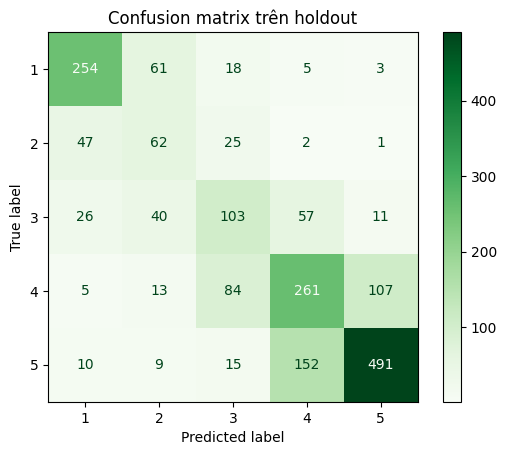

In [8]:
matrix = np.asarray(holdout_metrics['confusion_matrix'])
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=[1, 2, 3, 4, 5])
display.plot(cmap='Greens', values_format='d')
plt.title('Confusion matrix trên holdout')
plt.show()

## 5. Phân tích lỗi đúng index dữ liệu sạch

In [9]:
test_df = clean_df.iloc[test_index].copy().reset_index(drop=True)
test_df['predicted_rating'] = pipeline.predict(test_df['Review'])
test_df['rating_gap'] = (test_df['Rating'] - test_df['predicted_rating']).abs()
test_df['top_model_score'] = pipeline.predict_proba(test_df['Review']).max(axis=1)

error_columns = ['Review', 'Rating', 'predicted_rating', 'rating_gap', 'top_model_score']
test_df.sort_values(['rating_gap', 'top_model_score'], ascending=[False, False])[error_columns].head(20)

,Review,Rating,predicted_rating,rating_gap,top_model_score
1649,The delivery was faster than expected. I could...,5,1,4,0.626562
728,order was very fast,5,1,4,0.431407
817,I have ordered chicken shawarma with salad and...,5,1,4,0.419130
1795,"Ordered Chicken Biriyani after 2.30 pm, this w...",5,1,4,0.369573
834,"I was missing 4 teas, but then foodie monster ...",5,1,4,0.336964
1549,"Writing this review with stinky hands, Ambienc...",1,5,4,0.304020
552,Kya gaand wala khana banaye aapne.. sala kutta...,1,5,4,0.283838
1076,I was in Hyderabad for around 3 years... Durin...,5,1,4,0.282172
468,Lovely food\r\nLovely drinks with's make silu\...,5,1,4,0.281770
1465,yuck,1,5,4,0.278410


## 6. Kết luận

- Macro-F1 và MAE được ưu tiên hơn accuracy do dữ liệu lệch về 5 sao.
- Group split ngăn cùng nội dung xuất hiện ở cả train và test.
- Word và character TF-IDF giúp giữ từ phủ định và giảm ảnh hưởng lỗi chính tả.
- Model score chưa phải xác suất đã hiệu chỉnh.
- Cần dataset có nhãn riêng nếu muốn phát triển bài toán phát hiện giả mạo.